In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [2]:
df=pd.read_csv(r"/kaggle/input/nab/realTweets/realTweets/Twitter_volume_GOOG.csv")

# Data Cleaning Process

## 1. Validating Timestamp Column
- Converted the `timestamp` column to datetime using `pd.to_datetime`.
- Used `errors='coerce'` to handle invalid formats by converting them to `NaT`.
- Dropped rows with missing or invalid timestamps (`NaT`) to ensure chronological consistency.
- Sorted the dataset by `timestamp` for proper time series analysis.

## 2. Validating Value Column
- Checked for missing values in the `value` column.
- Dropped or imputed rows with `NaN` values depending on analysis needs.
- Ensured numeric type for `value` to allow calculations and plotting.

## 3. Final Dataset
- Cleaned dataset contains only valid timestamps and values.
- Ready for time series visualization and further analysis.

In [3]:
df['timestamp']=pd.to_datetime(df['timestamp'],errors='coerce')
df=df.dropna(subset=['timestamp'])
df=df.sort_values('timestamp').drop_duplicates('timestamp')

In [4]:
df['value']=pd.to_numeric(df['value'],errors='coerce')
df=df.dropna(subset=['value'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15842 entries, 0 to 15841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  15842 non-null  datetime64[ns]
 1   value      15842 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 247.7 KB


<Axes: >

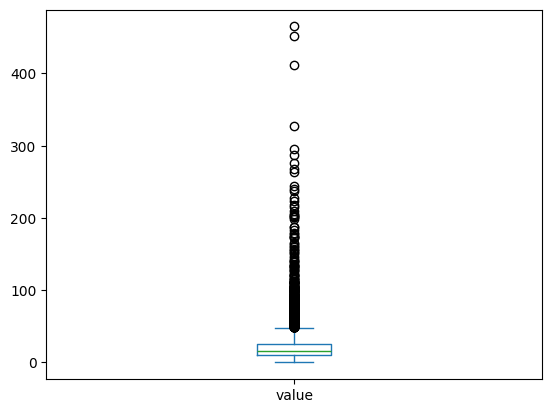

In [6]:
df['value'].plot(kind='box')

## Boxplot Interpretation

- The boxplot of `value` shows a right-skewed distribution with a dense central range.
- The median lies closer to the lower quartile, indicating asymmetry.
- Numerous outliers above the upper whisker suggest extreme high values.
- These outliers may represent anomalies, spikes, or noise in the data.

In [7]:
desc = df['value'].describe()
cleaned = desc.apply(lambda x: f"{int(x)}" if x == int(x) else f"{x:.2f}")
print(cleaned)

count    15842
mean     20.74
std      18.56
min          0
25%         11
50%         16
75%         26
max        465
Name: value, dtype: object


In [8]:
mean_val = df['value'].mean()
median_val = df['value'].median()
std_val = df['value'].std()
min_val = df['value'].min()
max_val = df['value'].max()

p1 = np.percentile(df['value'], 1)
p99 = np.percentile(df['value'], 99)

q1 = np.percentile(df['value'], 25)
q3 = np.percentile(df['value'], 75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = ((df['value'] < lower_fence) | (df['value'] > upper_fence)).sum()
print(f"Mean: {mean_val:.2f}, Median: {median_val:.2f}, Std Dev: {std_val:.2f}, Min: {min_val}, Max: {max_val}")
print(f"1st Percentile: {p1}, 99th Percentile: {p99}")
print(f"Outliers detected: {outliers}")

Mean: 20.74, Median: 16.00, Std Dev: 18.56, Min: 0, Max: 465
1st Percentile: 3.0, 99th Percentile: 86.0
Outliers detected: 836


In [9]:

Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
print("Lower Fence:", lower_fence)
print("Upper Fence:", upper_fence)

# Identify outliers
outliers_iqr = df[(df['value'] < lower_fence) | (df['value'] > upper_fence)]
print (outliers_iqr)


Lower Fence: -11.5
Upper Fence: 48.5
                timestamp  value
29    2015-02-27 00:07:53     59
31    2015-02-27 00:17:53     97
32    2015-02-27 00:22:53     61
33    2015-02-27 00:27:53    105
34    2015-02-27 00:32:53     52
...                   ...    ...
15836 2015-04-22 21:22:53     62
15837 2015-04-22 21:27:53     58
15838 2015-04-22 21:32:53     50
15840 2015-04-22 21:42:53     72
15841 2015-04-22 21:47:53     72

[836 rows x 2 columns]


In [10]:
lower_percentile = df['value'].quantile(0.01)  # 1st percentile
upper_percentile = df['value'].quantile(0.99)  # 99th percentile

print("1% cutoff:", lower_percentile)
print("99% cutoff:", upper_percentile)

# Identify outliers
outliers_pct = df[(df['value'] < lower_percentile) | (df['value'] > upper_percentile)]
print(outliers_pct)

1% cutoff: 3.0
99% cutoff: 86.0
                timestamp  value
31    2015-02-27 00:17:53     97
33    2015-02-27 00:27:53    105
57    2015-02-27 02:27:53     94
66    2015-02-27 03:12:53    187
67    2015-02-27 03:17:53    203
...                   ...    ...
15802 2015-04-22 18:32:53     94
15803 2015-04-22 18:37:53     87
15806 2015-04-22 18:52:53     98
15807 2015-04-22 18:57:53    102
15820 2015-04-22 20:02:53    106

[309 rows x 2 columns]


In [11]:
df=df.set_index('timestamp')
df=df.asfreq('h')

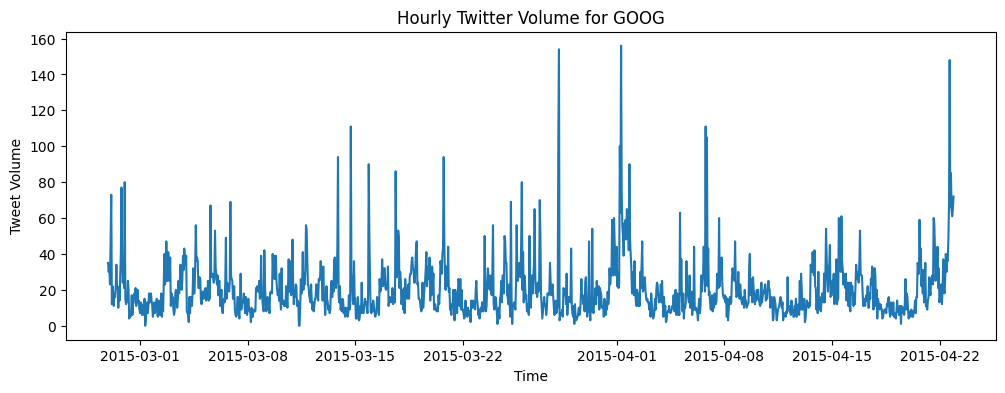

In [12]:
plt.figure(figsize=(12,4))
plt.plot(df['value'])
plt.title("Hourly Twitter Volume for GOOG")
plt.xlabel("Time")
plt.ylabel("Tweet Volume")
plt.show()


/tmp/ipykernel_17/538061131.py:2: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df_7d = df.last('7D')


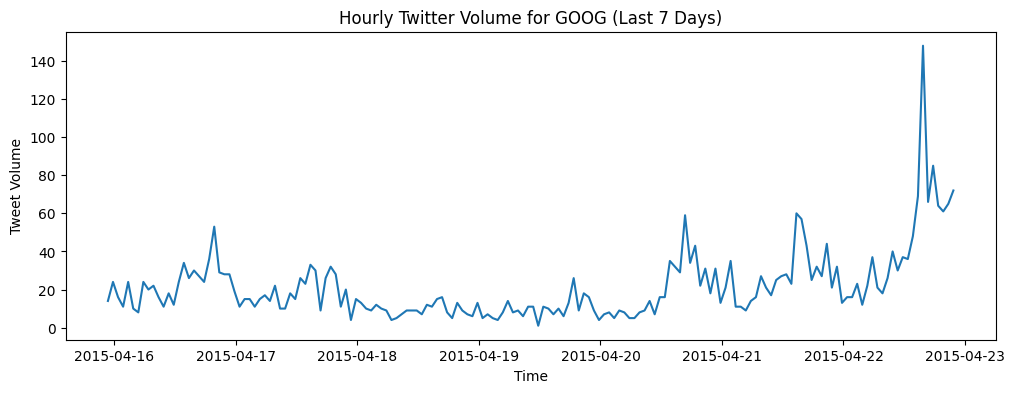

In [13]:
# Select last 7 days of data
df_7d = df.last('7D')

# Plot
plt.figure(figsize=(12,4))
plt.plot(df_7d.index, df_7d['value'])
plt.title("Hourly Twitter Volume for GOOG (Last 7 Days)")
plt.xlabel("Time")
plt.ylabel("Tweet Volume")
plt.show()


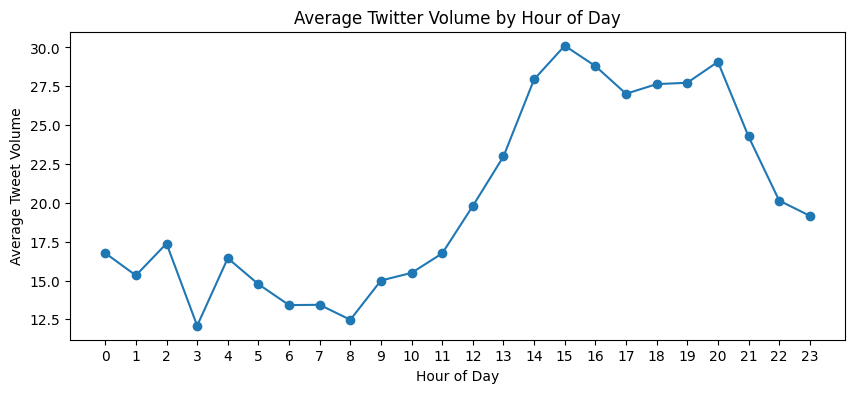

In [14]:
# Create hour-of-day column
df['hour'] = df.index.hour

# Average volume per hour
hourly_avg = df.groupby('hour')['value'].mean()

# Plot
plt.figure(figsize=(10,4))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title("Average Twitter Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Tweet Volume")
plt.xticks(range(0,24))
plt.show()


In [15]:
# Create day of week column (0=Monday, 6=Sunday)
df['day_of_week'] = df.index.dayofweek

# Label weekday vs weekend
df['day_type'] = df['day_of_week'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

In [16]:
avg_volume = df.groupby('day_type')['value'].mean()
avg_volume

day_type
Weekday    23.075774
Weekend    13.078125
Name: value, dtype: float64

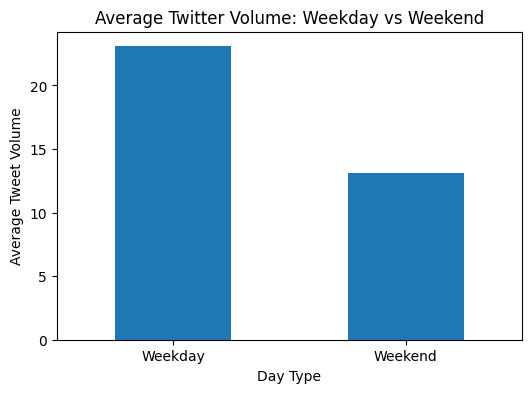

In [17]:
plt.figure(figsize=(6,4))
avg_volume.plot(kind='bar')
plt.title("Average Twitter Volume: Weekday vs Weekend")
plt.ylabel("Average Tweet Volume")
plt.xlabel("Day Type")
plt.xticks(rotation=0)
plt.show()


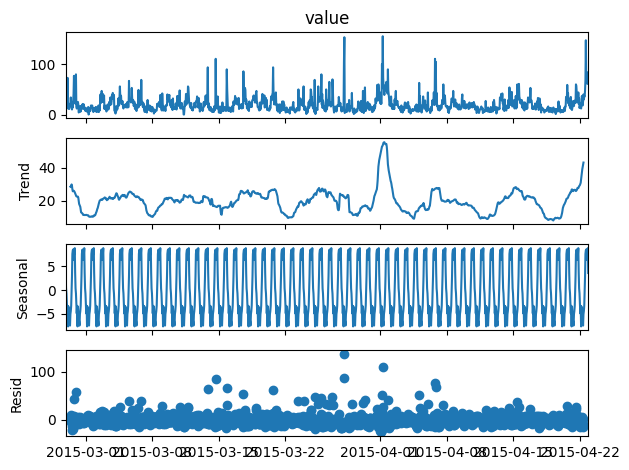

In [18]:
decomposition = seasonal_decompose(
    df['value'],
    model='additive',
    period=24
)

decomposition.plot()
plt.show()

## Seasonal Decomposition Analysis

Seasonal decomposition was applied to the hourly Twitter volume time series to separate it into its core structural components: the observed series, trend, seasonal pattern, and residuals. This analysis helps validate assumptions made during exploratory analysis and supports model selection.

---

### 1. Observed Series (Original Data)

The top panel represents the original hourly Twitter volume.

**Observations:**
- The series exhibits high short-term variability.
- Sudden spikes in tweet volume are present, indicating event-driven behavior.
- No smooth pattern is directly observable in the raw data.

**Interpretation:**
The raw series is dominated by noise and abrupt changes, making it difficult to directly identify underlying structure. This motivates the need for decomposition to isolate meaningful patterns.

---

### 2. Trend Component

The trend component captures the slow-moving baseline of Twitter activity over time.

**Observations:**
- The trend evolves smoothly without sharp jumps.
- Gradual rises and falls are visible.
- No long-term explosive growth or collapse is observed.

**Interpretation:**
The presence of a stable and smooth trend indicates that the overall level of Twitter activity changes gradually over time. This suggests that the system is stable and suitable for differencing-based time-series modeling.

---

### 3. Seasonal Component

The seasonal component represents repeating patterns in the data.

**Observations:**
- A clear and consistent wave-like pattern is visible.
- The pattern repeats regularly at fixed intervals.
- The shape and magnitude of the cycle remain stable over time.

**Interpretation:**
This component confirms the existence of strong daily seasonality in the data. The repeated 24-hour pattern reflects consistent intraday user behavior and justifies the use of a seasonal time-series model with a daily (24-hour) seasonal period.

---

### 4. Residual Component

The residual component captures what remains after removing the trend and seasonal effects.
**Observations:**
- Residuals are centered around zero.
- Large spikes appear occasionally.
- No repeating or systematic structure is visible.

**Interpretation:**
The residuals primarily consist of irregular, event-driven fluctuations rather than structured patterns. This indicates that trend and seasonality have been successfully extracted, and remaining variability corresponds to unpredictable external events.

---

### Overall Conclusion

The decomposition demonstrates that hourly Twitter activity is composed of:
- A stable underlying trend,
- A strong and consistent daily seasonal pattern,
- Event-driven noise captured in the residuals.

These findings validate the assumptions made during exploratory analysis and support the choice of a seasonal time-series model for short-term forecasting.

## Train and test

In [19]:
train = df.iloc[:-24]
test = df.iloc[-24:]

In [20]:
train.tail()

,value,hour,day_of_week,day_type
timestamp,,,,
2015-04-21 17:42:53,25,17,1,Weekday
2015-04-21 18:42:53,32,18,1,Weekday
2015-04-21 19:42:53,27,19,1,Weekday
2015-04-21 20:42:53,44,20,1,Weekday
2015-04-21 21:42:53,21,21,1,Weekday


In [21]:
test.head()

,value,hour,day_of_week,day_type
timestamp,,,,
2015-04-21 22:42:53,32,22,1,Weekday
2015-04-21 23:42:53,13,23,1,Weekday
2015-04-22 00:42:53,16,0,2,Weekday
2015-04-22 01:42:53,16,1,2,Weekday
2015-04-22 02:42:53,23,2,2,Weekday


# Sarimax

In [22]:
orders=(3,1,2)
seasonal_orders=(2,1,1,24)

In [23]:
model=SARIMAX(
    train['value'],
    order=orders,
    seasonal_order=seasonal_orders,
    enforce_invertibility=False,
    enforce_stationarity=False
)
result=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [24]:
forecast_24=result.forecast(steps=24)
y_true=test['value']
y_pred=forecast_24

In [25]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_squared_error
mae_24=mean_absolute_error(y_true,y_pred)
rmse_24=root_mean_squared_error(y_true,y_pred)
mae_24,rmse_24

(20.307903171874667, 31.086935702384668)

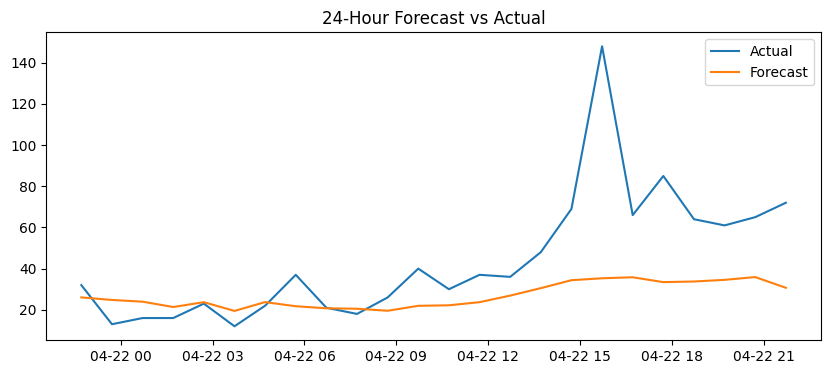

In [26]:
plt.figure(figsize=(10,4))
plt.plot(y_true.index, y_true, label="Actual")
plt.plot(y_true.index, y_pred, label="Forecast")
plt.title("24-Hour Forecast vs Actual")
plt.legend()
plt.show()

In [27]:
# last 7 day 
H_7d=168
train_7d=df.iloc[:-H_7d]
test_7d=df.iloc[-H_7d:]

In [28]:
train_7d.tail()

,value,hour,day_of_week,day_type
timestamp,,,,
2015-04-15 17:42:53,23,17,2,Weekday
2015-04-15 18:42:53,29,18,2,Weekday
2015-04-15 19:42:53,23,19,2,Weekday
2015-04-15 20:42:53,21,20,2,Weekday
2015-04-15 21:42:53,29,21,2,Weekday


In [29]:
train_7d.head()

,value,hour,day_of_week,day_type
timestamp,,,,
2015-02-26 21:42:53,35,21,3,Weekday
2015-02-26 22:42:53,30,22,3,Weekday
2015-02-26 23:42:53,33,23,3,Weekday
2015-02-27 00:42:53,23,0,4,Weekday
2015-02-27 01:42:53,48,1,4,Weekday


In [30]:
model_7d = SARIMAX(
    train_7d['value'],
    order=(2, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_7d = model_7d.fit()

forecast_7d = results_7d.forecast(steps=H_7d)


In [31]:
mae_7d = mean_absolute_error(test_7d['value'], forecast_7d)
rmse_7d = np.sqrt(mean_squared_error(test_7d['value'], forecast_7d))

mae_7d, rmse_7d

(12.432373227250164, np.float64(17.02254975607299))

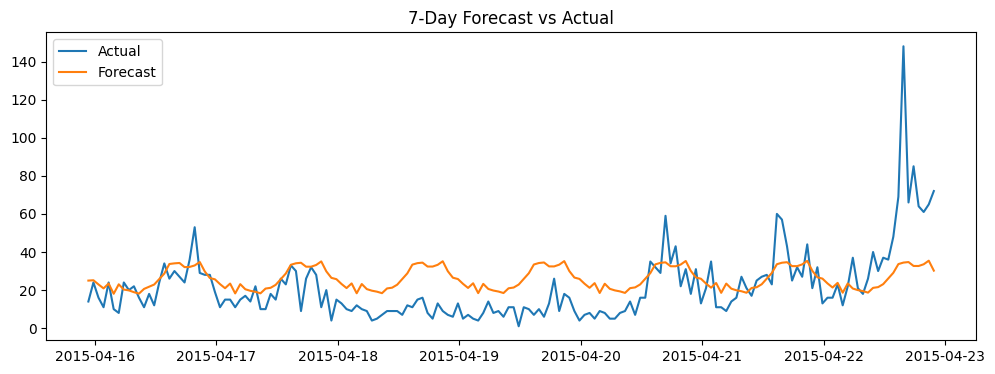

In [32]:
plt.figure(figsize=(12,4))
plt.plot(test_7d.index, test_7d['value'], label='Actual')
plt.plot(test_7d.index, forecast_7d, label='Forecast')
plt.title('7-Day Forecast vs Actual')
plt.legend()
plt.show()

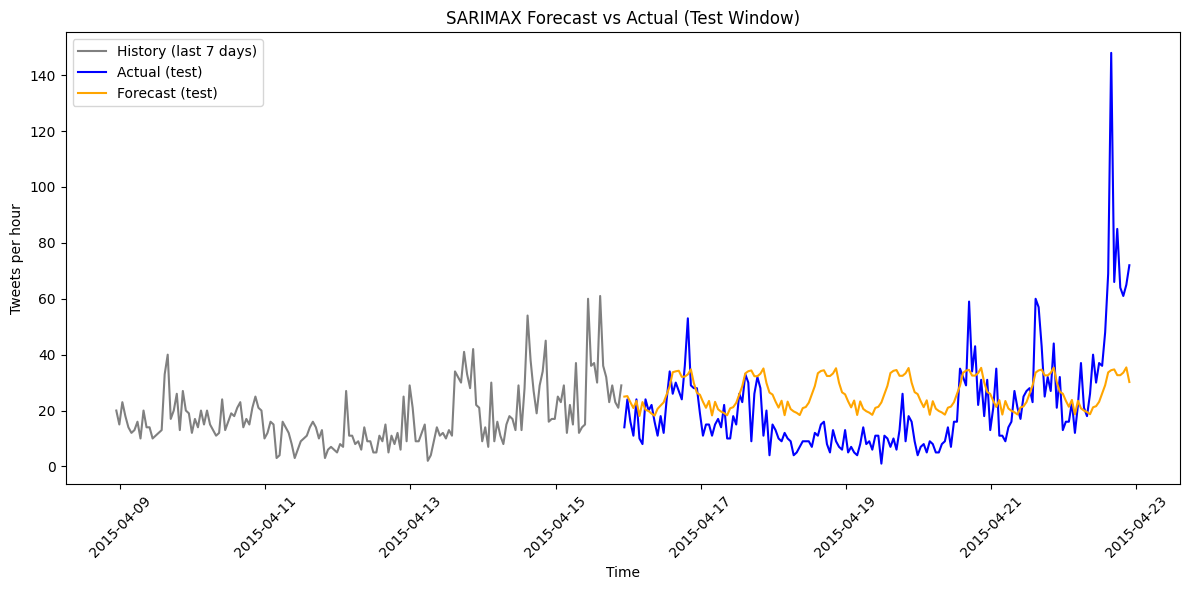

In [33]:
plt.figure(figsize=(12,6))
# 1 History (last 7 days before test, for context)
plt.plot(
    df.index[-(H_7d*2):-H_7d],
    df['value'][-(H_7d*2):-H_7d],
    label='History (last 7 days)',
    color='gray'
)

# 2 Actual test values
plt.plot(
    test_7d.index,
    test_7d['value'],
    label='Actual (test)',
    color='blue'
)

# 3 Forecast for test window
plt.plot(
    test_7d.index,
    forecast_7d,
    label='Forecast (test)',
    color='orange'
)

plt.title('SARIMAX Forecast vs Actual (Test Window)')
plt.xlabel('Time')
plt.ylabel('Tweets per hour')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_model = SARIMAX(
    df['value'],
    order=orders,
    seasonal_order=seasonal_orders,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_res = final_model.fit()

In [35]:
next_steps = 24

final_pred = final_res.get_forecast(steps=next_steps)

final_mean = final_pred.predicted_mean
final_conf = final_pred.conf_int(alpha=0.05)

In [36]:
future_index = pd.date_range(
    start=df.index[-1] + pd.Timedelta(hours=1),
    periods=next_steps,
    freq='H'
)

/tmp/ipykernel_17/3223144825.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(


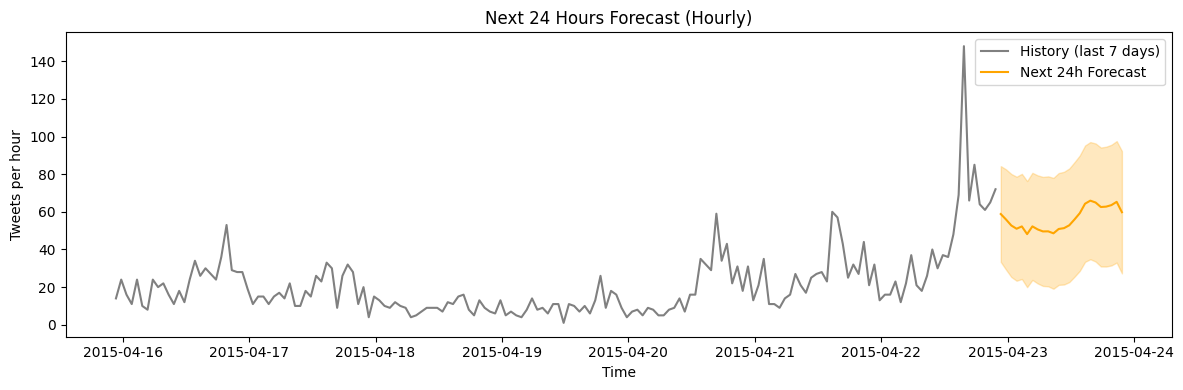

In [37]:
plt.figure(figsize=(12,4))

# Context: last 7 days
plt.plot(
    df.index[-7*24:],
    df['value'][-7*24:],
    label='History (last 7 days)',
    color='gray'
)

# Forecast
plt.plot(
    future_index,
    final_mean.values,
    label='Next 24h Forecast',
    color='orange'
)

# Confidence interval
plt.fill_between(
    future_index,
    final_conf.iloc[:, 0],
    final_conf.iloc[:, 1],
    color='orange',
    alpha=0.25
)

plt.title('Next 24 Hours Forecast (Hourly)')
plt.xlabel('Time')
plt.ylabel('Tweets per hour')
plt.legend()
plt.tight_layout()
plt.show()


In [38]:
forecast_df = pd.DataFrame({
    'timestamp': future_index,
    'forecast': final_mean.values,
    'lower_95': final_conf.iloc[:, 0].values,
    'upper_95': final_conf.iloc[:, 1].values
})

forecast_df.head()

,timestamp,forecast,lower_95,upper_95
0,2015-04-22 22:42:53,58.821766,33.374015,84.269517
1,2015-04-22 23:42:53,55.906846,29.268490,82.545201
2,2015-04-23 00:42:53,52.736584,25.382974,80.090193
3,2015-04-23 01:42:53,51.016083,23.390266,78.641900
4,2015-04-23 02:42:53,52.247055,24.312571,80.181538
